In [1]:
options(warn = -1)
options(repr.plot.width = 15, repr.plot.height = 9)
Sys.setlocale(category = "LC_ALL",locale = "ko_KR.UTF-8") 

[1] "ko_KR.UTF-8/ko_KR.UTF-8/ko_KR.UTF-8/C/ko_KR.UTF-8/C.UTF-8"

## 가설 검정
### 카이제곱 검정
: 두 범주형 변수가 서로 상관이 있는지 판단하는 통계적 검정 방법.    
예: 학력, 성별, 직업의 만족도      

#### child별 장난감 보유 현황
- 귀무가설 : child1과 child2의 장난감 보유수에 대한 만족도는 차이가 없다. 
- 대립가설 : child1과 child2의 장난감 보유수에 대한 만족도의 차이가 있다. 

In [2]:
# child별 장난감 보유 현황
child1 <- c(5, 11, 1)
child2 <- c(4, 7, 3)

In [4]:
# 분석을 위해 데이터 합치기
Toy <- cbind(child1, child2)
rownames(Toy) <- c("car", "truck", "doll")
Toy

,child1,child2
car,5,4
truck,11,7
doll,1,3


In [5]:
# 카이제곱 검정
chisq.test(Toy)


	Pearson's Chi-squared test

data:  Toy
X-squared = 1.7258, df = 2, p-value = 0.4219


p-value = 0.04219 > 0.05(95% 신뢰구간) -> 귀무가설  
child1과 child2의 데이터는 통계적으로 큰 차이가 없다.

In [ ]:
# 상관계수
cor(child1, child2) # 차이가 없으니까 상관이 없는것

[1] 0.9862414

#### t-검정


In [7]:
# 귀무가설 : 건전지의 수명은 1000 시간이다.
# 대립가설 : 건전지의 수명은 1000 시간이 아니다.

In [9]:
# 데이터의 분포가 정규분포인지 확인 --> sharpiro-wilk 검정
# 귀무가설 : 자료가 정규분포에 따른다.
# 대립가설 : 자료가 정규분포를 따르지 않는다.   

bat <- c(980, 1008, 968, 1032, 1012, 1002, 996, 1017) # 광고하는 시간은 평균값이라
shapiro.test(bat)


	Shapiro-Wilk normality test

data:  bat
W = 0.97706, p-value = 0.9469


p-value = 0.9469 > 0.05 --> 귀무가설

In [ ]:
# t-검정
t.test(
    bat,
    mu=1000,
    alternative = 'two.sided'
)

# mu : 비교하는 대상
# alternative
# - two.shided : 데이터가 평균과 다르다.
# - greater : 데이터가 평균보다 크다.
# - less : 데이터가 평균보다 작다.


	One Sample t-test

data:  bat
t = 0.25891, df = 7, p-value = 0.8032
alternative hypothesis: true mean is not equal to 1000
95 percent confidence interval:
  984.7508 1018.9992
sample estimates:
mean of x 
 1001.875 


p-value = 0.8032 > 0.05 -> 귀무가설

In [12]:
# 이 배터리는 1000 시간이 맞다고 증명 하는 것

In [15]:
exam <- read.csv("../Data/exam.csv")
exam

no,score
<int>,<int>
1,58
2,49
3,39
4,99
5,32
6,88
7,62
8,30
9,55


In [13]:
# 어떤 학급의 수학 점수 평균 : 55점 
# 0교시 수업을 한 후에 학생들의 성적이 올랐을까?
# 귀무가설 : 성적은 오르지 않았다.
# 대립가설 : 

In [16]:
a <- exam$score
# 정규 분포확인
shapiro.test(a)


	Shapiro-Wilk normality test

data:  a
W = 0.91143, p-value = 0.1058


 p-value = 0.1058 >0.05 -> 귀무가설

In [17]:
mean(a)

[1] 56.17647

In [18]:
# t검정
t.test(a, mu = 55, alternative = "greater")


	One Sample t-test

data:  a
t = 0.24546, df = 16, p-value = 0.4046
alternative hypothesis: true mean is greater than 55
95 percent confidence interval:
 47.80855      Inf
sample estimates:
mean of x 
 56.17647 


p - value = 0.4046 > 0.05  -> 귀무가설

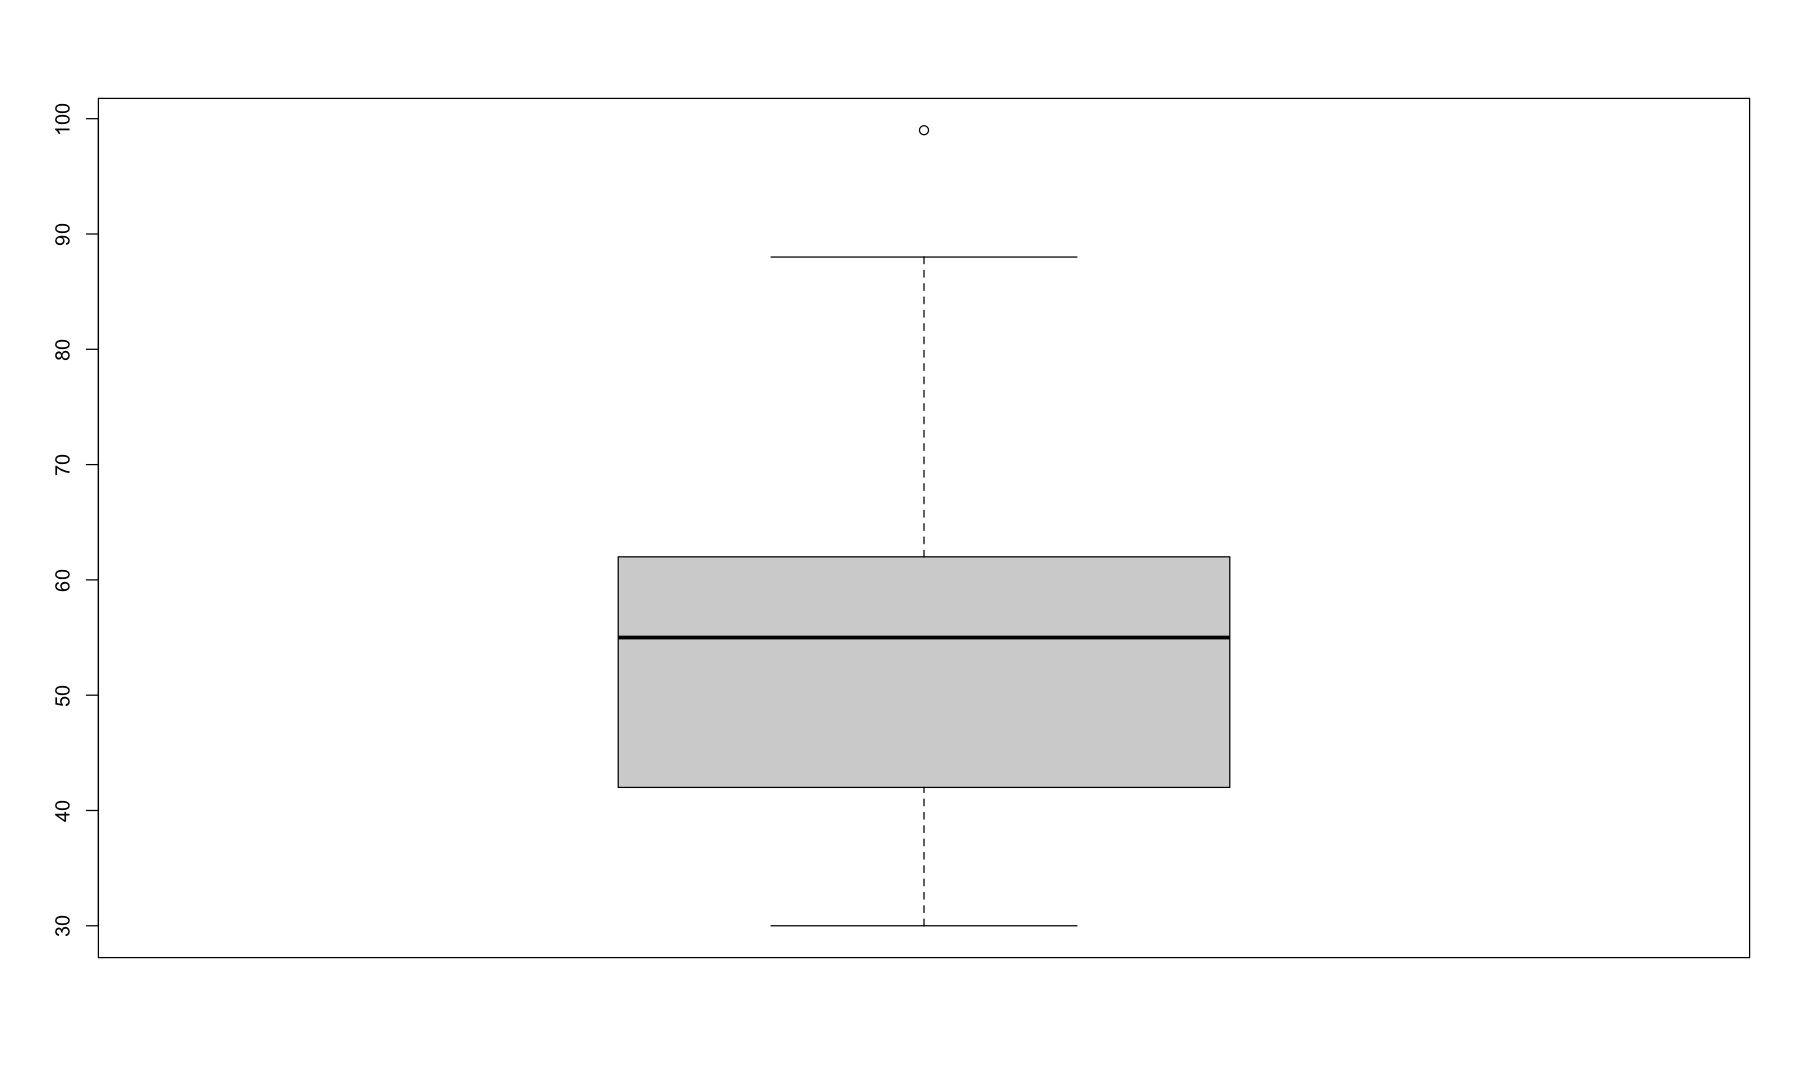

In [20]:
par(bg = 'white')
boxplot(exam$score) # 이상치가 없다.

#### 콜모고로프-스미노프 검정 (KS Test)
: 주어진 2개의 데이터가 같은 분포인지 검정

In [22]:
# 귀무가설 : 두개의 데이터 분포가 같다 
# 대립가설 : 두개의 데이터 분포가 다르다 

In [23]:
x <- rnorm(50)
y <- runif(50)

ks.test(x,y)


	Exact two-sample Kolmogorov-Smirnov test

data:  x and y
D = 0.46, p-value = 3.801e-05
alternative hypothesis: two-sided


p-value = 1.453e-07 < 0.05 -> 대립가설

#### 부호검정
: 2개의 데이터 사이에 차이가 있는지 검정

In [25]:
# 식사전과 식사후의 음료수 맛에 대한 평가
x <- c(4,1,1,4,3,3,2,5,3,3)
y <- c(1,1,3,2,5,1,4,4,3,1)

In [24]:
# 귀무가설 : 유의한 차이가 없다.
# 대립가설 : 유의한 차이가 있다.

In [26]:
binom.test(c(length(x[x>y]), length(x[x<y])))


	Exact binomial test

data:  c(length(x[x > y]), length(x[x < y]))
number of successes = 5, number of trials = 8, p-value = 0.7266
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.2448632 0.9147666
sample estimates:
probability of success 
                 0.625 


p - value = 0.7266 > 0.05 -> 귀무가설

#### 비율 검정
: 2개의 데이터 사이에 비율의 차이가 있는지 검정

In [27]:
# 맥주를 좋아하시나요? 라는 질문에 서울에서는 400명중 360명, 부산에서는 200명중 136명이 좋아한다고 답했다면 
# 둘의 비율 차이가 있다고 할수 있는가?

# 귀무가설 : 유의한 차이가 없다
# 대립가설 : 유의한 차이가 있다 
hite <- c(360,136)
sampleData <- c(400,200)

prop.test(hite,sampleData)


	2-sample test for equality of proportions with continuity correction

data:  hite out of sampleData
X-squared = 43.515, df = 1, p-value = 4.207e-11
alternative hypothesis: two.sided
95 percent confidence interval:
 0.14523 0.29477
sample estimates:
prop 1 prop 2 
  0.90   0.68 


p - value = 4.207e-11 < 0.05 -> 대립가설